In [175]:
# Import Dependencies
import jax
import jax.numpy as np
from memo import memo

import matplotlib.pyplot as plt

# The simplest memo function
All memo functions return JAX arrays. This serves as the JAX equivalent of a NumPy ndarray or a TensorFlow/PyTorch tensor, but with key distinctions tailored for JAX's high-performance numerical computing and machine learning capabilities.

We define a memo function using the @memo decorator

In [39]:
@memo
def f():
    return 1

In [40]:
f()

Array(1, dtype=int32, weak_type=True)

In [41]:
type(f())

jaxlib._jax.ArrayImpl

# Adding dimensions to a memo function
For each item in x, perform some computation on it 

In [44]:
x = [1,2,3]

@memo
def g[a:x]():
    return a*4 

g()

Array([ 4,  8, 12], dtype=int32)

In [45]:
@memo
def h[a:x, b:x]():
    return a*4 + b
h()

Array([[ 5,  6,  7],
       [ 9, 10, 11],
       [13, 14, 15]], dtype=int32)

# Enumerations (This is a Python, not memo thing)
Utterances are "green", "pink", "round" , "square"  
Referents are "green square", "green circle", "pink circle"

We use an enumeration type to associate strings to numbers

In [72]:
from enum import IntEnum

class Utterances(IntEnum):
    GREEN = 0 
    PINK = 1 
    ROUND = 2 
    SQUARE = 3

class Referents(IntEnum):
    GREEN_SQUARE = 0 
    GREEN_CIRCLE= 1 
    PINK_SQUARE = 2


In [49]:
Utterances.GREEN

<Utterances.GREEN: 0>

In [50]:
list(Utterances)

[<Utterances.GREEN: 0>,
 <Utterances.PINK: 1>,
 <Utterances.ROUND: 2>,
 <Utterances.SQUARE: 3>]

# Array Broadcasting
Perform arithmetic operations on arrays of different shapes without reshaping them.

In [71]:
# Notice how it is 4x1
@memo 
def L_1[ut:Utterances, ref: Referents]():
    return ut
L_1() 

Array([[0],
       [1],
       [2],
       [3]], dtype=int32)

In [75]:
# Notice how it is 1x3 
@memo
def L_2[ut:Utterances, ref: Referents]():
    return ref
L_2()

Array([[0, 1, 2]], dtype=int32)

In [81]:
# Notice how it is 4x1 X 1x3  = 4 x 3 
@memo
def L_3[ut:Utterances, ref: Referents]():
    return ut + ref
L_3()

Array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4],
       [3, 4, 5]], dtype=int32)

# Model of an agent making a choice. Then getting the probability of that outcome

In [203]:
# wpp = with probability proportional 
# Write some function of u, that gives the probability distribution of u

# This gives the probability of a speakers utterance drawn from a uniform distribution being equal to 0. 
# Since there are 4 possible utterances, we get 1/4 probability.
@memo
def L_4():
    speaker: chooses(u in Utterances, wpp=1)
    return Pr[speaker.u == 0]
L_4()

Array(0.25, dtype=float32)

In [204]:

# This gives the probability of a speakers utterance drawn from a uniform distribution being equal to the utterance
# Returns the whole distribution of utterances.

@memo
def L_5[ut: Utterances]():
    speaker: chooses(u in Utterances, wpp=1)
    return Pr[speaker.u == ut]
L_5()

Array([0.25, 0.25, 0.25, 0.25], dtype=float32)

# Going beyond uniform probability didstributions
The denotes function is just the probability distribution of drawing an utterance given that referent
Not a memo thing, but need to learn to think in terms of probability distributions! We are passing this into wpp

In [208]:
# Row is the utterance 
# Column is the referent
@jax.jit
def denotes(u, r):
    return np.array([[1,1,0],
                     [0,0,1],
                     [0,1,0],
                     [1,0,1]])[u,r]

@memo
def L_6[ut: Utterances]():
    speaker: chooses(r in Referents, wpp=1)
    speaker: chooses(u in Utterances, wpp=denotes(u,r))
    return Pr[speaker.u == ut]

In [209]:
# Gives the probability distribution of u
L_6()

Array([0.33333334, 0.16666667, 0.16666667, 0.33333334], dtype=float32)

In [210]:
# Every time you use square brackets, you're entering into another agent's mind
# This is syntatically valid model of the speaker, but it doesn't make sense for listener to know the whole distribtion
@memo
def L_7[ut: Utterances]():
    listener: knows(ut)
    listener: thinks[
        speaker: chooses(r in Referents, wpp=1), 
        speaker: chooses(u in Utterances, wpp=denotes(u,r))
    ]

    # return Pr[speaker.u == ut] 
    # return Pr[listener[speaker[u]] == ut] We can't do this as listener does not have access to speakers actions
    return listener[Pr[speaker[u] == ut]]

In [211]:
L_7()

Array([0.33333334, 0.16666667, 0.16666667, 0.33333334], dtype=float32)

In [213]:
# Rather than using knows, we use observe instead?
# This makes more sense, as the listener observes something specific
@memo
def L_8[ut: Utterances]():
    listener: thinks[
        speaker: chooses(r in Referents, wpp=1), 
        speaker: chooses(u in Utterances, wpp=denotes(u,r))
    ]
    listener: observes[speaker.u] is ut
    return listener[Pr[speaker.r == 0]]
L_8()

Array([0.5, 0. , 0. , 0.5], dtype=float32)

In [214]:
@memo
def L1[ut: Utterances, ref: Referents]():
    listener: knows(ref)
    listener: thinks[
        speaker: chooses(r in Referents, wpp=1), 
        speaker: chooses(u in Utterances, wpp=denotes(u,r))
    ]
    listener: observes[speaker.u] is ut
    return listener[Pr[speaker.r == ref]]
L1()

Array([[0.5, 0.5, 0. ],
       [0. , 0. , 1. ],
       [0. , 1. , 0. ],
       [0.5, 0. , 0.5]], dtype=float32)

# Make it recursive

In [217]:
@memo
def L2[ut: Utterances, ref: Referents]():
    listener: knows(ref)
    listener: thinks[
        speaker: chooses(r in Referents, wpp=1), 
        speaker: chooses(u in Utterances, wpp=L1[u,r]())
    ]
    listener: observes[speaker.u] is ut
    return listener[Pr[speaker.r == ref]]

In [158]:
L2()

Array([[0.59999996, 0.4       , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.        ],
       [0.59999996, 0.        , 0.4       ]], dtype=float32)

In [173]:
@memo
def L2_softmax[ut: Utterances, ref: Referents](beta=1.5):
    listener: knows(ref)
    listener: thinks[
        speaker: chooses(r in Referents, wpp=1), 
        speaker: chooses(u in Utterances, wpp=exp(L1[u,r]()*beta) * denotes(u,r))
    ]
    listener: observes[speaker.u] is ut
    return listener[Pr[speaker.r == ref]]

L2_softmax(10)

@memo
def L_n[ut: Utterances, ref: Referents](beta=1.5, n=2):
    listener: knows(ref)
    listener: thinks[
        speaker: chooses(r in Referents, wpp=1), 
        speaker: chooses(u in Utterances, wpp=exp(L_n[u,r](beta,n-1)*beta) * denotes(u,r) if n >1 else denotes(u,r))
    ]
    listener: observes[speaker.u] is ut
    return listener[Pr[speaker.r == ref]]

L_n(10,4)

Array([[9.999091e-01, 9.088159e-05, 0.000000e+00],
       [0.000000e+00, 0.000000e+00, 1.000000e+00],
       [0.000000e+00, 1.000000e+00, 0.000000e+00],
       [9.999091e-01, 0.000000e+00, 9.088159e-05]], dtype=float32)

# Plot something!

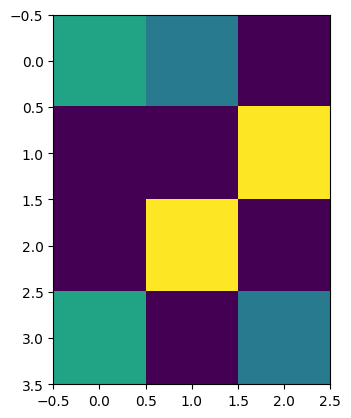

In [178]:
plt.imshow(L_n(1,4))

# Fit the model to human data

In [185]:
Y= np.array([[0.85, 0.15, 0. ],
            [0. , 0. , 1. ], 
            [0. , 1., 0. ], 
            [0.45, 0. , 0.55]])
@jax.jit
def loss(beta):
    pred = L_n(beta, 3)
    return np.mean(((pred - Y)**2))
            

In [191]:
all_betas = np.linspace(0,10,100)
errors = jax.vmap(loss)(all_betas)

Text(0, 0.5, 'error')

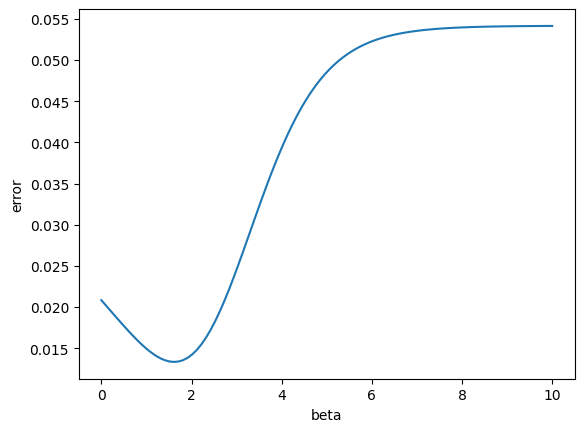

In [196]:
plt.plot(all_betas,errors)
plt.xlabel("beta")
plt.ylabel("error")

In [202]:
current_beta = 4.0
step_size = 2

for i in range(100):
    val, grad = jax.value_and_grad(loss)(current_beta)
    current_beta = current_beta - step_size * grad
    if i % 5 == 0:
        print("at", i, ":", val, "\t with beta:", current_beta )

at 0 : 0.039331548 	 with beta: 3.9745436
at 5 : 0.037611574 	 with beta: 3.8421457
at 10 : 0.035668146 	 with beta: 3.7015777
at 15 : 0.033515275 	 with beta: 3.5538902
at 20 : 0.031196076 	 with beta: 3.4009714
at 25 : 0.028786633 	 with beta: 3.2455752
at 30 : 0.02638961 	 with beta: 3.0911195
at 35 : 0.024115814 	 with beta: 2.9412415
at 40 : 0.022059757 	 with beta: 2.7992303
at 45 : 0.020280872 	 with beta: 2.6675572
at 50 : 0.018798213 	 with beta: 2.5476568
at 55 : 0.017597944 	 with beta: 2.439987
at 60 : 0.01664652 	 with beta: 2.3442547
at 65 : 0.015902828 	 with beta: 2.2596881
at 70 : 0.015326379 	 with beta: 2.1852698
at 75 : 0.014881457 	 with beta: 2.1199033
at 80 : 0.014538518 	 with beta: 2.0625155
at 85 : 0.014274022 	 with beta: 2.012111
at 90 : 0.01406965 	 with beta: 1.9677958
at 95 : 0.013911325 	 with beta: 1.9287822
